## Model Exp 3


In [3]:
import os
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.preprocessing.image import load_img, img_to_array
from tkinter import Tk, filedialog  # For file selection pop-up

# ==========================================
# 1. CONFIGURATION
# ==========================================
# Replace with the path to your best .keras model
MODEL_PATH = r'Exp3_DenseNet121_best_model.keras'

# Image size (MUST be the same as during training)
IMG_SIZE = (224, 224)

# List of labels (make sure the order is correct, usually alphabetical by folder)
# Adjust according to your dataset folder names
class_names = [
    'Fresh', 'Spoiled'
]

# ==========================================
# 2. PREDICTION FUNCTION
# ==========================================
def predict_image(model, image_path):
    try:
        # A. Load & preprocess the image
        # Target size must match the model input shape
        img_original = load_img(image_path)
        img = load_img(image_path, target_size=IMG_SIZE)
        
        # Convert to array
        x = img_to_array(img)
        
        # IMPORTANT: Normalize (0–255 -> 0–1)
        # If this step is forgotten, predictions may be incorrect!
        x = x / 255.0
        
        # Add batch dimension (model expects input [Batch, Height, Width, Channel])
        # From (224, 224, 3) to (1, 224, 224, 3)
        x = np.expand_dims(x, axis=0)
        
        # B. Prediction
        predictions = model.predict(x)
        score = tf.nn.softmax(predictions[0])  # Convert to probabilities
        
        # Get index with highest probability
        predicted_class_idx = np.argmax(predictions[0])
        predicted_label = class_names[predicted_class_idx]
        confidence = np.max(predictions[0]) * 100  # Percentage

        # C. Display results
        plt.figure(figsize=(6, 6))
        plt.imshow(img_original)
        plt.axis('off')
        
        result_text = f"Prediction: {predicted_label}\nConfidence: {confidence:.2f}%"
        plt.title(result_text, color='green' if confidence > 80 else 'red', fontsize=14)
        plt.show()
        
        print(f"\n---> RESULT: {predicted_label}")
        print(f"---> Confidence: {confidence:.2f}%")
        
        # Show probability details for all classes (optional)
        print("\nProbability Details:")
        for i, prob in enumerate(predictions[0]):
            print(f"{class_names[i]}: {prob*100:.2f}%")
            
    except Exception as e:
        print(f"Error: {e}")

Loading model... (please wait)
✅ Model loaded successfully!

Processing: C:/Users/Azvadennys/Downloads/data testing crop terbaru-20260224T045720Z-1-001/data testing crop terbaru/segar/20200517_084316.jpg
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step


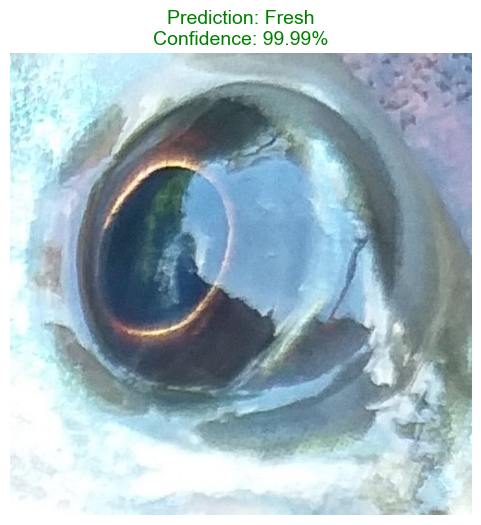


---> RESULT: Fresh
---> Confidence: 99.99%

Probability Details:
Fresh: 99.99%
Spoiled: 0.01%

Processing: C:/Users/Azvadennys/Downloads/data testing crop terbaru-20260224T045720Z-1-001/data testing crop terbaru/tidak segar baru/20200517_145439.jpg
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step


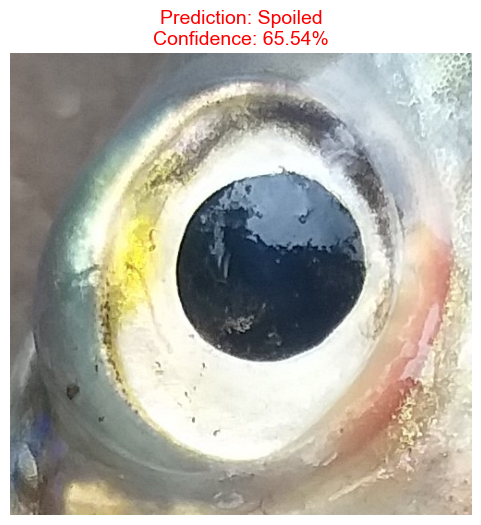


---> RESULT: Spoiled
---> Confidence: 65.54%

Probability Details:
Fresh: 34.46%
Spoiled: 65.54%


In [4]:
if not os.path.exists(MODEL_PATH):
    print(f"❌ Model not found at: {MODEL_PATH}")
    print("Please fix the MODEL_PATH at the top of the code.")
else:
    print("Loading model... (please wait)")
    model = tf.keras.models.load_model(MODEL_PATH)
    print("✅ Model loaded successfully!")

    while True:
        choice = input("\nPress [ENTER] to choose an image, or type 'q' to quit: ")
        if choice.lower() == 'q':
            break

        # Open the file picker window
        root = Tk()
        root.withdraw()  # Hide the main Tkinter window
        root.attributes('-topmost', True)  # Bring the pop-up to the front

        file_path = filedialog.askopenfilename(
            title="Select an Edible Film Image",
            filetypes=[("Image Files", "*.png;*.jpg;*.jpeg;*.bmp")]
        )

        if file_path:
            print(f"\nProcessing: {file_path}")
            predict_image(model, file_path)
        else:
            print("No file was selected.")

# Convert to TF LITE

In [5]:
import tensorflow as tf
import numpy as np
import os

# ==========================================
# 1. CONFIGURATION
# ==========================================
# Path to your best .keras model
MODEL_PATH = r'Exp3_DenseNet121_best_model.keras'
TFLITE_PATH = 'model_fisheye.tflite'
LABELS_PATH = 'labels.txt'

# Class list (must be in alphabetical order, matching the training folders!)
class_names = [
    'Fresh', 'Spoiled'
]

# ==========================================
# 2. CONVERSION PROCESS
# ==========================================
print(f"Loading model from: {MODEL_PATH}")
model = tf.keras.models.load_model(MODEL_PATH)

# Converter
converter = tf.lite.TFLiteConverter.from_keras_model(model)

# (Optional) Optimization to make the file smaller & faster on mobile
converter.optimizations = [tf.lite.Optimize.DEFAULT]

print("Converting to TFLite...")
tflite_model = converter.convert()

# Save the .tflite file
with open(TFLITE_PATH, 'wb') as f:
    f.write(tflite_model)
print(f"✅ Success! TFLite model saved to: {TFLITE_PATH}")

# Save the labels.txt file
with open(LABELS_PATH, 'w') as f:
    for label in class_names:
        f.write(label + '\n')
print(f"✅ Success! Labels saved to: {LABELS_PATH}")

Loading model from: Exp3_DenseNet121_best_model.keras
Converting to TFLite...
INFO:tensorflow:Assets written to: C:\Users\AZVADE~1\AppData\Local\Temp\tmp7rhn8xmk\assets


INFO:tensorflow:Assets written to: C:\Users\AZVADE~1\AppData\Local\Temp\tmp7rhn8xmk\assets


Saved artifact at 'C:\Users\AZVADE~1\AppData\Local\Temp\tmp7rhn8xmk'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 224, 224, 3), dtype=tf.float32, name='input_layer_1')
Output Type:
  TensorSpec(shape=(None, 2), dtype=tf.float32, name=None)
Captures:
  1819192663728: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1819192689232: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1819192690288: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1819192679408: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1819192689056: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1819192730192: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1819192731248: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1819192712176: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1819192730016: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1819192743008: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1

## Ekstrak Citra

In [8]:
!pip install opencv-python

  Obtaining dependency information for opencv-python from https://files.pythonhosted.org/packages/13/de/291cbb17f44242ed6bfd3450fc2535d6bd298115c0ccd6f01cd51d4a11d7/opencv_python-4.13.0.90-cp37-abi3-win_amd64.whl.metadata
   ---------------------------------------- 0.0/40.2 MB ? eta -:--:--
   ---------------------------------------- 0.0/40.2 MB 2.0 MB/s eta 0:00:20
   ---------------------------------------- 0.1/40.2 MB 787.7 kB/s eta 0:00:51
   ---------------------------------------- 0.2/40.2 MB 1.1 MB/s eta 0:00:35
   ---------------------------------------- 0.2/40.2 MB 1.1 MB/s eta 0:00:35
   ---------------------------------------- 0.3/40.2 MB 1.4 MB/s eta 0:00:30
   ---------------------------------------- 0.4/40.2 MB 1.5 MB/s eta 0:00:26
    --------------------------------------- 0.6/40.2 MB 1.8 MB/s eta 0:00:23
    --------------------------------------- 0.7/40.2 MB 2.1 MB/s eta 0:00:20
    --------------------------------------- 0.9/40.2 MB 2.2 MB/s eta 0:00:18
   - --------


[notice] A new release of pip is available: 23.2.1 -> 25.3
[notice] To update, run: python.exe -m pip install --upgrade pip


Loading model...
Model loaded successfully!
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step


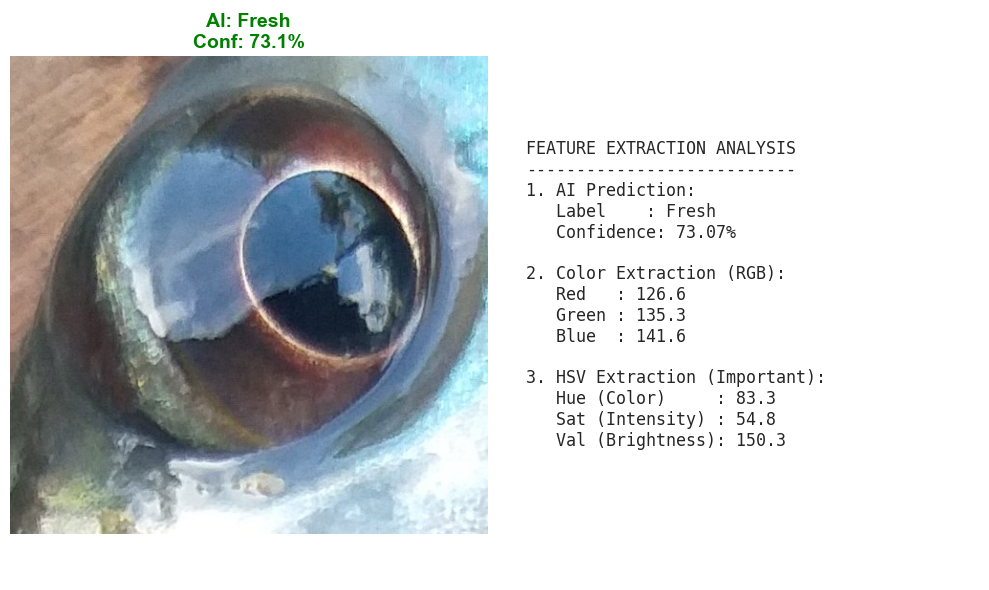


FULL ANALYSIS RESULT
AI prediction : Fresh (73.07%)
Mean RGB: (126.6, 135.3, 141.6)
Mean HSV: (83.3, 54.8, 150.3)


In [8]:
import os
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
import cv2  # We use OpenCV for accurate color conversion
from tensorflow.keras.preprocessing.image import load_img, img_to_array
from tkinter import Tk, filedialog

# ==========================================
# 1. CONFIGURATION
# ==========================================
MODEL_PATH = r'Exp3_DenseNet121_best_model.keras'  # Adjust the path as needed
IMG_SIZE = (224, 224)
CLASS_NAMES = ['Fresh', 'Spoiled']

# ==========================================
# 2. FEATURE EXTRACTION FUNCTION (RGB & OTHERS)
# ==========================================
def extract_color_features(image_path):
    """
    Compute the mean RGB and HSV values of an image.
    """
    # Read the image using OpenCV (default format is BGR)
    img_bgr = cv2.imread(image_path)
    # Convert to RGB (OpenCV uses BGR, Matplotlib uses RGB)
    img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
    # Convert to HSV (Hue, Saturation, Value) - very useful for freshness detection
    img_hsv = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2HSV)

    # 1. Compute mean RGB
    mean_r = np.mean(img_rgb[:, :, 0])
    mean_g = np.mean(img_rgb[:, :, 1])
    mean_b = np.mean(img_rgb[:, :, 2])

    # 2. Compute mean HSV
    # Hue: color type (0-179), Saturation: intensity (0-255), Value: brightness (0-255)
    mean_h = np.mean(img_hsv[:, :, 0])
    mean_s = np.mean(img_hsv[:, :, 1])
    mean_v = np.mean(img_hsv[:, :, 2])

    return {
        'R': mean_r, 'G': mean_g, 'B': mean_b,
        'H': mean_h, 'S': mean_s, 'V': mean_v,
        'img_rgb': img_rgb  # Return the image array for display
    }

# ==========================================
# 3. MAIN PREDICTION FUNCTION
# ==========================================
def predict_and_analyze(model_path):
    # Load the model
    print("Loading model...")
    try:
        model = tf.keras.models.load_model(model_path)
        print("Model loaded successfully!")
    except Exception as e:
        print(f"Failed to load model: {e}")
        return

    # Select a file
    root = Tk()
    root.withdraw()
    file_path = filedialog.askopenfilename(title="Select a Fish/Oil Image")
    root.destroy()

    if not file_path:
        print("No file was selected.")
        return

    try:
        # A. Manual feature analysis (RGB, etc.)
        features = extract_color_features(file_path)

        # B. Preprocessing for AI
        img = load_img(file_path, target_size=IMG_SIZE)
        x = img_to_array(img)
        x = x / 255.0  # Normalization (IMPORTANT!)
        x = np.expand_dims(x, axis=0)  # Add batch dimension

        # C. AI prediction
        predictions = model.predict(x)

        # Output logic (check whether it's Binary Sigmoid or Categorical Softmax)
        if predictions.shape[-1] == 1:
            # Binary (Sigmoid)
            score = predictions[0][0]
            predicted_label = CLASS_NAMES[1] if score > 0.5 else CLASS_NAMES[0]
            confidence = score * 100 if score > 0.5 else (1 - score) * 100
        else:
            # Categorical (Softmax)
            score_array = tf.nn.softmax(predictions[0])
            idx = np.argmax(score_array)
            predicted_label = CLASS_NAMES[idx]
            confidence = np.max(score_array) * 100

        # ==========================================
        # 4. FULL VISUALIZATION
        # ==========================================
        plt.figure(figsize=(10, 6))

        # Plot image
        plt.subplot(1, 2, 1)
        plt.imshow(features['img_rgb'])
        plt.axis('off')

        # Image title (AI result)
        # Green if Fresh, red if Spoiled
        color_title = 'green' if predicted_label == 'Fresh' else 'red'
        plt.title(
            f"AI: {predicted_label}\nConf: {confidence:.1f}%",
            color=color_title, fontsize=14, weight='bold'
        )

        # Plot statistics (text info)
        plt.subplot(1, 2, 2)
        plt.axis('off')

        # Statistics text
        info_text = (
            f"FEATURE EXTRACTION ANALYSIS\n"
            f"---------------------------\n"
            f"1. AI Prediction:\n"
            f"   Label    : {predicted_label}\n"
            f"   Confidence: {confidence:.2f}%\n\n"

            f"2. Color Extraction (RGB):\n"
            f"   Red   : {features['R']:.1f}\n"
            f"   Green : {features['G']:.1f}\n"
            f"   Blue  : {features['B']:.1f}\n\n"

            f"3. HSV Extraction (Important):\n"
            f"   Hue (Color)     : {features['H']:.1f}\n"
            f"   Sat (Intensity) : {features['S']:.1f}\n"
            f"   Val (Brightness): {features['V']:.1f}"
        )

        plt.text(
            0.05, 0.5, info_text,
            fontsize=12, family='monospace', verticalalignment='center'
        )
        plt.tight_layout()
        plt.show()

        # Also print to console
        print("\n" + "=" * 30)
        print("FULL ANALYSIS RESULT")
        print("=" * 30)
        print(f"AI prediction : {predicted_label} ({confidence:.2f}%)")
        print(f"Mean RGB: ({features['R']:.1f}, {features['G']:.1f}, {features['B']:.1f})")
        print(f"Mean HSV: ({features['H']:.1f}, {features['S']:.1f}, {features['V']:.1f})")

    except Exception as e:
        print(f"An error occurred: {e}")

# Run the program
if __name__ == "__main__":
    predict_and_analyze(MODEL_PATH)

Loading the AI model...
Model is ready.


1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step


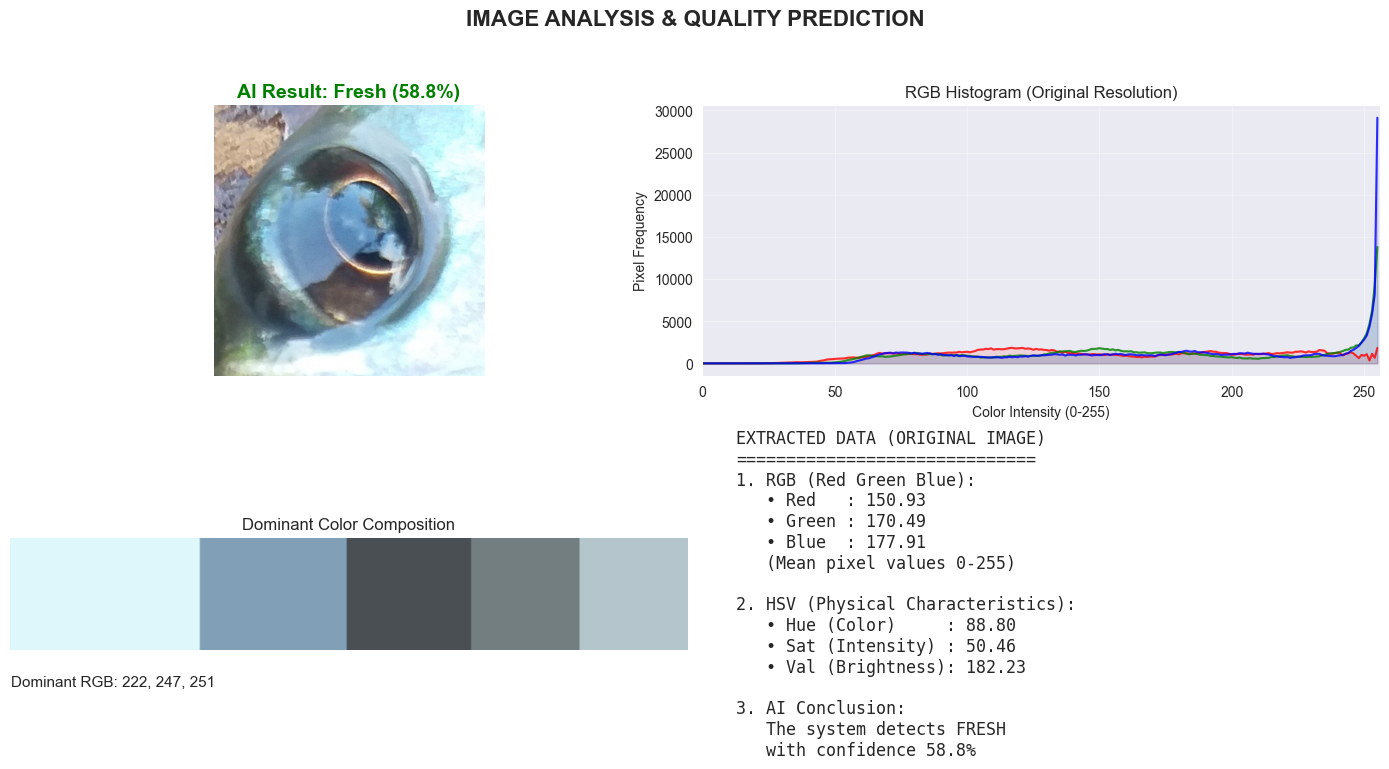

------------------------------
Prediction: Fresh
Original RGB: R=150.93, G=170.49, B=177.91
------------------------------


In [9]:
import os
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
import cv2
from tkinter import Tk, filedialog
from sklearn.cluster import KMeans

# ==========================================
# 1. CONFIGURATION
# ==========================================
# Replace with your model path
MODEL_PATH = r'Exp3_DenseNet121_best_model.keras'
IMG_SIZE = (224, 224)  # Input size required by the AI model
CLASS_NAMES = ['Fresh', 'Spoiled']

# ==========================================
# 2. COLOR ANALYSIS FUNCTIONS (FROM THE ORIGINAL IMAGE)
# ==========================================
def analyze_original_color(image_bgr_original):
    """
    Takes an ORIGINAL-resolution BGR image from OpenCV.
    Computes statistics without resizing the image.
    """
    # 1. Convert to RGB (important because OpenCV uses BGR)
    img_rgb = cv2.cvtColor(image_bgr_original, cv2.COLOR_BGR2RGB)

    # 2. Convert to HSV (useful for analyzing brightness/yellowing)
    img_hsv = cv2.cvtColor(image_bgr_original, cv2.COLOR_BGR2HSV)

    # 3. Compute mean values over all original pixels
    # axis=(0, 1) means averaging over width and height, keeping the 3 channels
    mean_rgb = np.mean(img_rgb, axis=(0, 1))
    mean_hsv = np.mean(img_hsv, axis=(0, 1))

    return img_rgb, mean_rgb, mean_hsv


def get_dominant_palette(img_rgb, k=5):
    """
    Finds k dominant colors.
    For K-Means speed, we temporarily resize a copy (not the original data).
    """
    # Resize only to speed up K-Means (does not significantly affect the color values)
    # Running K-Means on a 12MP image would be very slow.
    img_small = cv2.resize(img_rgb, (100, 100), interpolation=cv2.INTER_AREA)
    img_flat = img_small.reshape((img_small.shape[0] * img_small.shape[1], 3))

    clt = KMeans(n_clusters=k, n_init=10, random_state=42)
    clt.fit(img_flat)

    # Compute percentages
    numLabels = np.arange(0, len(np.unique(clt.labels_)) + 1)
    (hist, _) = np.histogram(clt.labels_, bins=numLabels)
    hist = hist.astype("float")
    hist /= hist.sum()

    # Sort by dominance
    zipped = sorted(zip(hist, clt.cluster_centers_), key=lambda x: x[0], reverse=True)

    # Create a visualization bar
    bar = np.zeros((50, 300, 3), dtype="uint8")
    start_x = 0
    top_color = zipped[0][1]  # Most dominant color

    for (percent, color) in zipped:
        end_x = start_x + (percent * 300)
        cv2.rectangle(
            bar, (int(start_x), 0), (int(end_x), 50),
            color.astype("uint8").tolist(), -1
        )
        start_x = end_x

    return bar, top_color

# ==========================================
# 3. MAIN FUNCTION
# ==========================================
def main_process():
    # A. Load the model
    print("Loading the AI model...")
    try:
        model = tf.keras.models.load_model(MODEL_PATH)
        print("Model is ready.")
    except Exception as e:
        print(f"Error loading model: {e}")
        return

    # B. Select a file
    root = Tk()
    root.withdraw()
    file_path = filedialog.askopenfilename(title="Select an Image (Fish/Oil)")
    root.destroy()

    if not file_path:
        return

    try:
        # --- STEP 1: READ ORIGINAL IMAGE DATA ---
        # Read with OpenCV (full resolution)
        img_bgr_orig = cv2.imread(file_path)
        if img_bgr_orig is None:
            print("The image is corrupted or the format is not supported.")
            return

        # Color analysis on original data
        img_rgb_orig, mean_rgb, mean_hsv = analyze_original_color(img_bgr_orig)
        palette_bar, top_color = get_dominant_palette(img_rgb_orig)

        # --- STEP 2: PREPARE INPUT FOR AI (RESIZE & NORMALIZE) ---
        # Resize a copy for the neural network input
        img_for_ai = cv2.resize(img_rgb_orig, IMG_SIZE)
        img_for_ai = img_for_ai / 255.0  # Normalize to 0–1
        img_for_ai = np.expand_dims(img_for_ai, axis=0)  # Add batch dimension

        # Predict
        preds = model.predict(img_for_ai)

        # Detect model output type (Binary vs Categorical)
        if preds.shape[-1] == 1:
            score = preds[0][0]
            pred_idx = 1 if score > 0.5 else 0
            conf = score if score > 0.5 else 1 - score
        else:
            pred_idx = np.argmax(preds)
            conf = np.max(preds)

        label = CLASS_NAMES[pred_idx]

        # --- STEP 3: DASHBOARD VISUALIZATION ---
        plt.figure(figsize=(14, 8))
        plt.suptitle("IMAGE ANALYSIS & QUALITY PREDICTION", fontsize=16, weight='bold')

        # [Panel 1] Original image & AI result
        plt.subplot(2, 2, 1)
        plt.imshow(img_rgb_orig)
        plt.axis('off')
        color_res = 'green' if label == 'Fresh' else 'red'
        plt.title(f"AI Result: {label} ({conf*100:.1f}%)", color=color_res, fontsize=14, weight='bold')

        # [Panel 2] RGB histogram (from original data)
        plt.subplot(2, 2, 2)
        plt.title("RGB Histogram (Original Resolution)")
        colors = ('r', 'g', 'b')
        for i, col in enumerate(colors):
            # Compute histogram from img_rgb_orig (NOT the resized version)
            hist = cv2.calcHist([img_rgb_orig], [i], None, [256], [0, 256])
            plt.plot(hist, color=col, alpha=0.8, linewidth=1.5)
            plt.fill_between(range(256), hist.flatten(), color=col, alpha=0.1)

        plt.xlim([0, 256])
        plt.ylabel("Pixel Frequency")
        plt.xlabel("Color Intensity (0-255)")
        plt.grid(True, alpha=0.3)

        # [Panel 3] Dominant color palette
        plt.subplot(2, 2, 3)
        plt.imshow(palette_bar)
        plt.axis('off')
        plt.title("Dominant Color Composition")
        plt.text(0, 65, f"Dominant RGB: {int(top_color[0])}, {int(top_color[1])}, {int(top_color[2])}", fontsize=11)

        # [Panel 4] Detailed statistics
        plt.subplot(2, 2, 4)
        plt.axis('off')

        stats_text = (
            f"EXTRACTED DATA (ORIGINAL IMAGE)\n"
            f"==============================\n"
            f"1. RGB (Red Green Blue):\n"
            f"   • Red   : {mean_rgb[0]:.2f}\n"
            f"   • Green : {mean_rgb[1]:.2f}\n"
            f"   • Blue  : {mean_rgb[2]:.2f}\n"
            f"   (Mean pixel values 0-255)\n\n"

            f"2. HSV (Physical Characteristics):\n"
            f"   • Hue (Color)     : {mean_hsv[0]:.2f}\n"
            f"   • Sat (Intensity) : {mean_hsv[1]:.2f}\n"
            f"   • Val (Brightness): {mean_hsv[2]:.2f}\n\n"

            f"3. AI Conclusion:\n"
            f"   The system detects {label.upper()}\n"
            f"   with confidence {conf*100:.1f}%"
        )

        plt.text(0.05, 0.5, stats_text, fontsize=12, family='monospace', verticalalignment='center')

        plt.tight_layout(rect=[0, 0.03, 1, 0.95])
        plt.show()

        # Print text output
        print("-" * 30)
        print(f"Prediction: {label}")
        print(f"Original RGB: R={mean_rgb[0]:.2f}, G={mean_rgb[1]:.2f}, B={mean_rgb[2]:.2f}")
        print("-" * 30)

    except Exception as e:
        print(f"An error occurred during processing: {e}")
        import traceback
        traceback.print_exc()

if __name__ == "__main__":
    main_process()